# Final Activity

In [1]:
# We import all required libraries for our analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import root_mean_squared_error, ConfusionMatrixDisplay, confusion_matrix

### Import and verify dataset

In [2]:
data = pd.read_csv("data/gym_churn_us.csv")
data.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


aaa

In [3]:
# We define the predictor and target columns for our analysis
predictors_columns = ["gender", "Near_Location", "Partner", "Promo_friends", "Phone", "Contract_period", "Group_visits", "Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]
target_column = "Churn"

# We split the data into training and testing sets
predictors, target = data[predictors_columns], data[target_column]
data_train, data_test, target_train, target_test = train_test_split(predictors, target, random_state=42)

## Logistic Regression Analysis

In [4]:
# Train a logistic regression model
linear_model = LogisticRegression(max_iter=1000)
linear_model.fit(data_train, target_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
# Evaluate the model on the test set
test_score = linear_model.score(data_test, target_test)
print(f"Accuracy of the LogisticRegression: {test_score:.4f}")
test_predictions = linear_model.predict(data_test)
rmse = root_mean_squared_error(y_true = target_test, y_pred = test_predictions)
print(f"Root Mean Square Error : {rmse:.4f}")

Accuracy of the LogisticRegression: 0.9260
Root Mean Square Error : 0.2720


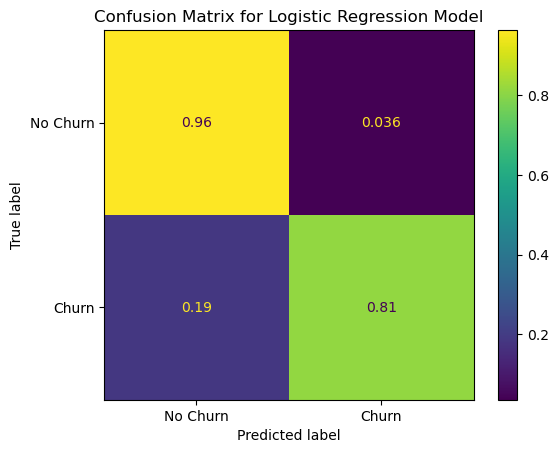

In [6]:
ConfusionMatrixDisplay.from_predictions(target_test, test_predictions, display_labels=["No Churn", "Churn"], normalize="true")
plt.title("Confusion Matrix for Logistic Regression Model")
plt.grid(False)
plt.show()

## Decision Tree Analysis

In [7]:
# Train a decision tree model
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(data_train, target_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [8]:
# Evaluate the model on the test set
test_score = tree_model.score(data_test, target_test)
print(f"Accuracy of the Decision Tree: {test_score:.4f}")
test_predictions = tree_model.predict(data_test)
rmse = root_mean_squared_error(y_true = target_test, y_pred = test_predictions)
print(f"Root Mean Square Error : {rmse:.4f}")

Accuracy of the Decision Tree: 0.8870
Root Mean Square Error : 0.3362


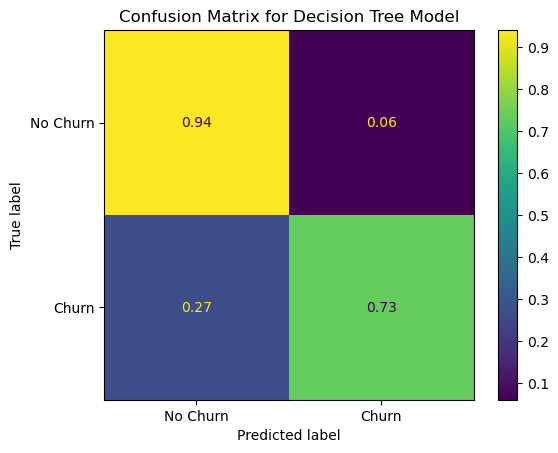

In [9]:
ConfusionMatrixDisplay.from_predictions(target_test, test_predictions, display_labels=["No Churn", "Churn"], normalize="true")
plt.title("Confusion Matrix for Decision Tree Model")
plt.grid(False)
plt.show()

## Random Forest Analysis

In [10]:
# Train a random forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(data_train, target_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
# Evaluate the model on the test set
test_score = rf_model.score(data_test, target_test)
print(f"Accuracy of the Random Forest: {test_score:.4f}")
test_predictions = rf_model.predict(data_test)
rmse = root_mean_squared_error(y_true = target_test, y_pred = test_predictions)
print(f"Root Mean Square Error : {rmse:.4f}")

Accuracy of the Random Forest: 0.9160
Root Mean Square Error : 0.2898


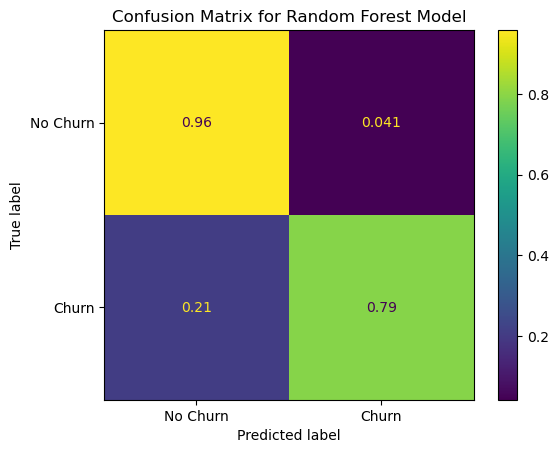

In [12]:
ConfusionMatrixDisplay.from_predictions(target_test, test_predictions, display_labels=["No Churn", "Churn"], normalize="true")
plt.title("Confusion Matrix for Random Forest Model")
plt.grid(False)
plt.show()

### Decision of the model to use

In [13]:
# USER INPUT!!!!!
# From the following poll, decide the model you want to use
# 1. Logistic (Logistic Regression)
# 2. Tree (Decision Tree)
# 3. Random (Random Forest)
model_used = "Logistic"

def select_model(model_used):
    if model_used == "Logistic":
        return linear_model
    elif model_used == "Tree":
        return tree_model
    elif model_used == "Random":
        return rf_model
    else:
        raise ValueError("Invalid model choice. Please choose 'Logistic', 'Tree', or 'Random'.")

## Retention Campaign Analysis
**Definition of useful functions:**
- `optimize_threshold(model, cost_matrix, target_test)`: This function iterates through different threshold values to find the one that maximizes the total revenue based on the cost matrix and confusion matrix.
- `calculate_payoff(conf_matrix, cost_matrix)`: This function calculates the payoff matrix by multiplying the confusion matrix with the cost matrix and then sums up the total revenue.
- `plot_threshold_revenue(threshold_revenues)`: This function plots the relationship between different threshold values and their corresponding total revenues.

In [14]:
def calculate_payoff(con_matrix, cost_matrix):
    payoff_matrix = cost_matrix * con_matrix
    total_revenue = np.sum(payoff_matrix)
    return payoff_matrix, total_revenue

def plot_threshold_revenue(threshold_revenues):
    thresholds, revenues = zip(*threshold_revenues)
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, revenues, color='blue')
    plt.title('Total Revenue vs. Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Total Revenue ($)')
    plt.grid()
    plt.show()

def optimize_threshold(model, cost_matrix, target_test, num_thresholds = 2000):
    thresholds = np.linspace(0, 1, num_thresholds)
    best_threshold = 0
    best_revenue = -np.inf
    best_payoff_matrix = None
    best_conf_matrix = None
    threshold_revenues = []


    for threshold in thresholds:
        test_predictions = (model.predict_proba(data_test)[:, 1] > threshold).astype('float')
        conf_matrix = confusion_matrix(target_test, test_predictions)
        payoff_matrix, total_revenue = calculate_payoff(conf_matrix, cost_matrix)
        threshold_revenues.append((threshold, total_revenue))

        if total_revenue > best_revenue:
            best_revenue = total_revenue
            best_threshold = threshold
            best_payoff_matrix = payoff_matrix
            best_conf_matrix = conf_matrix

    plot_threshold_revenue(threshold_revenues)

    return best_threshold, best_revenue, best_payoff_matrix, best_conf_matrix

### Campaign No. 1

**Cost Matrix:**

|                  | Will Stay (No promotion sent) | Will Leave (Promotion sent) |
|------------------|-------------------------------|-----------------------------|
| Intends to Stay  | $10,000            | $9,500             |
| Intends to Leave | $0                 | $3,500             |

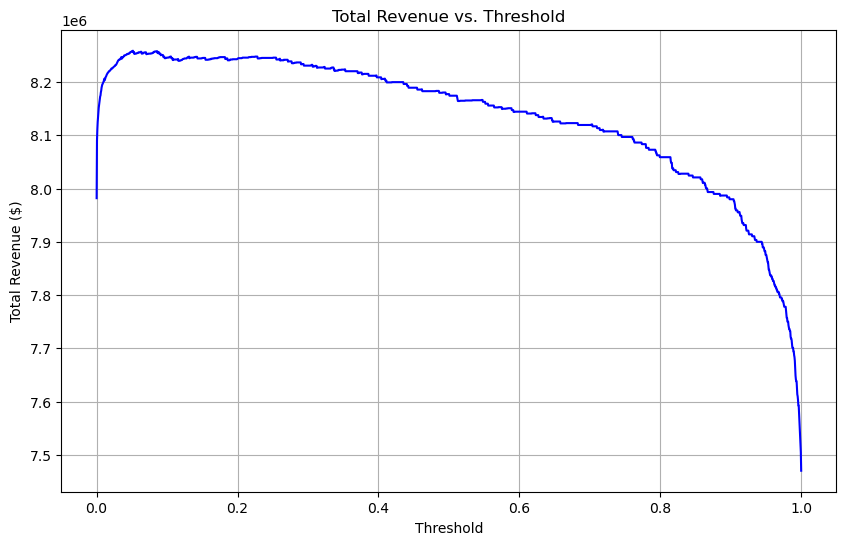

Best Threshold:  0.051525762881440715
Cost Matrix: 
 [[10000  9500]
 [    0  3500]]
Confusion Matrix: 
 [[575 172]
 [  3 250]]
Payoff Matrix: 
 [[5750000 1634000]
 [      0  875000]]
Total Revenue of the Campaign: $ 8259000


In [15]:
model = select_model(model_used)

cost_matrix = np.array([[10000, 9500],
                        [0, 3500]])


best_threshold, best_revenue, best_payoff_matrix, best_conf_matrix = optimize_threshold(model, cost_matrix, target_test)

print("Best Threshold: ", best_threshold)
print("Cost Matrix: \n", cost_matrix)
print("Confusion Matrix: \n", best_conf_matrix)
print("Payoff Matrix: \n", best_payoff_matrix)
print("Total Revenue of the Campaign: $", best_revenue)

## Campaign No. 2

**Cost Matrix:**

|                  | Will Stay (No promotion sent) | Will Leave (Promotion sent) |
|------------------|-------------------------------|-----------------------------|
| Intends to Stay  | $10,000            | $9,800             |
| Intends to Leave | $0                 | $1,800             |

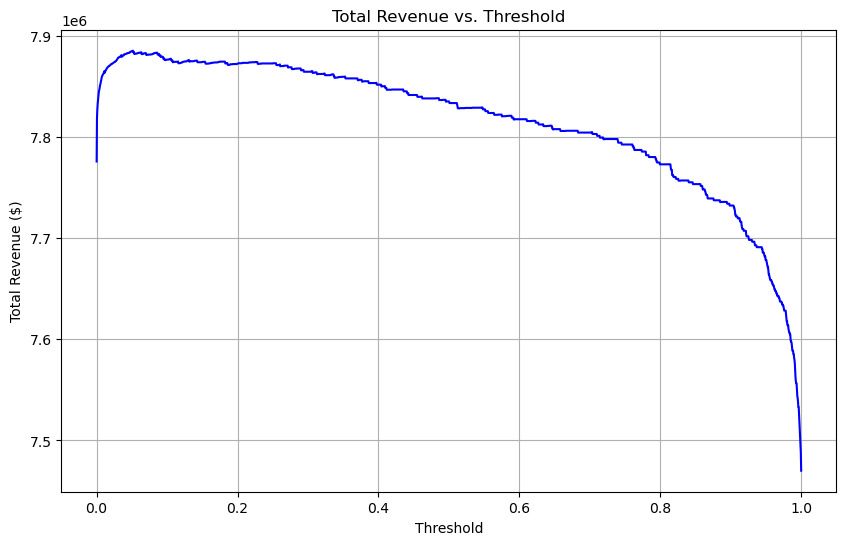

Best Threshold:  0.051525762881440715
Cost Matrix: 
 [[10000  9800]
 [    0  1800]]
Confusion Matrix: 
 [[575 172]
 [  3 250]]
Payoff Matrix: 
 [[5750000 1685600]
 [      0  450000]]
Total Revenue of the Campaign: $ 7885600


In [16]:
cost_matrix = np.array([[10000, 9800],
                        [0, 1800]])

best_threshold, best_revenue, best_payoff_matrix, best_conf_matrix = optimize_threshold(model, cost_matrix, target_test)

print("Best Threshold: ", best_threshold)
print("Cost Matrix: \n", cost_matrix)
print("Confusion Matrix: \n", best_conf_matrix)
print("Payoff Matrix: \n", best_payoff_matrix)
print("Total Revenue of the Campaign: $", best_revenue)

### Campaign No. 3

**Cost Matrix:**

|                  | Will Stay (No promotion sent) | Will Leave (Promotion sent) |
|------------------|-------------------------------|-----------------------------|
| Intends to Stay  | $10,000            | $8,800             |
| Intends to Leave | $0                 | $5,800             |

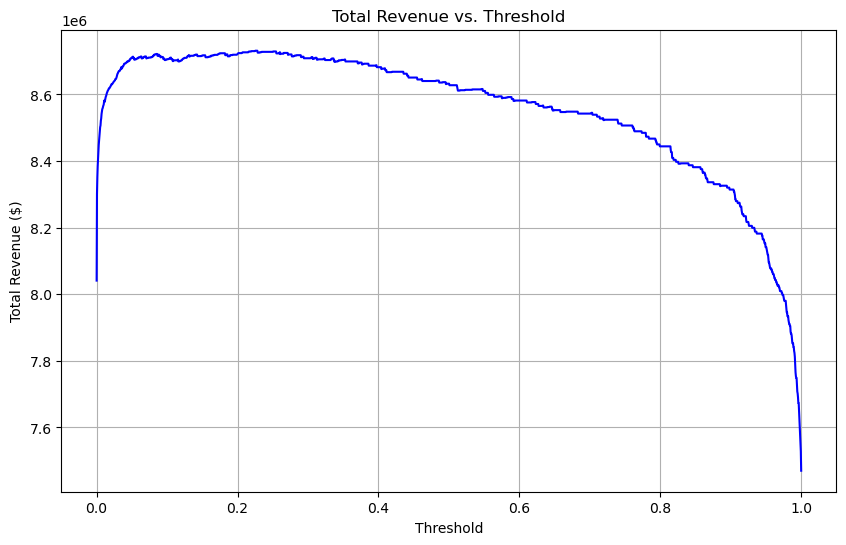

Best Threshold:  0.22511255627813906
Cost Matrix: 
 [[10000  8800]
 [    0  5800]]
Confusion Matrix: 
 [[672  75]
 [ 20 233]]
Payoff Matrix: 
 [[6720000  660000]
 [      0 1351400]]
Total Revenue of the Campaign: $ 8731400


In [17]:
cost_matrix = np.array([[10000, 8800],
                        [0, 5800]])

best_threshold, best_revenue, best_payoff_matrix, best_conf_matrix = optimize_threshold(model, cost_matrix, target_test)

print("Best Threshold: ", best_threshold)
print("Cost Matrix: \n", cost_matrix)
print("Confusion Matrix: \n", best_conf_matrix)
print("Payoff Matrix: \n", best_payoff_matrix)
print("Total Revenue of the Campaign: $", best_revenue)